# 🔬 Centralized Experiment Runner & Scientific Evaluation Dashboard

Welcome to the centralized dashboard for your deep learning rotation robustness research on **ModelNet10**. This notebook acts as the unified cockpit to orchestrate, evaluate, and compare all your baselines, from scratch-trained models to transfer-learned ResNet18 variants.

### 📍 Experimental Workflow
1. **Train**: Run custom CNNs (`ModelS`) or Transfer Learning (`ModelT`) experiments.
2. **Evaluate**: Extract overall metrics, generate confusion matrices, and measure viewpoint sensitivity over all 12 angles.
3. **Compare**: Create publication-grade comparative rotation curves and generate your statistical results CSV.

> **💡 GPU Memory Tip:** To prevent CUDA memory fragmentation and ensure reproducibility, we spawn separate processes for training runs. This releases GPU resources cleanly between experiments.

In [1]:
import os
import sys
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure project root is in path for custom module loading
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f"📂 Working Directory set to Project Root: {os.getcwd()}")
print(f"🖥️ CUDA Available: {os.popen('nvidia-smi').read() != ''}")

📂 Working Directory set to Project Root: /home/nofa/School/Masters/SSC/DL_Project
🖥️ CUDA Available: True


## 🛠️ Step 1: Load and View Available Configurations

All experiment specs are declared in `configs/experiments.yaml`. Let's parse and display what we can run.

In [2]:
with open("configs/experiments.yaml", "r") as f:
    experiments = yaml.safe_load(f)

print("🚀 Available Experiments in Config File:")
print(json.dumps(experiments, indent=4))

🚀 Available Experiments in Config File:
{
    "S-1": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": false
    },
    "S-2": {
        "model": "model_s",
        "optimizer": "sgd",
        "lr": 0.01,
        "momentum": 0.9,
        "nesterov": true,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": false
    },
    "S-3": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": true
    },
    "S-4": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "label_smoothing",
        "augmentation": false
    },
    "T-FE-1": {
        "model": "model_t",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmenta

## ⚙️ Step 2: Centralized Process Launcher

Use this section to train any of the experiments dynamically.

In [3]:
def run_experiment(exp_name):
    """
    Spawns a training run for a given experiment config.
    """
    print(f"\n🔥 Launching Experiment: {exp_name}...")
    cmd = f"PYTHONPATH=. uv run python scripts/run_experiment.py --exp {exp_name}"
    # Run and stream output
    os.system(cmd)
    print(f"✅ Finished training/verifying {exp_name}.")

In [4]:
# Example: Train S-3 (CNN with Augmentations)
# run_experiment("S-3")

# Example: Train T-FE-1 (ResNet18 Feature Extraction, No Aug)
# run_experiment("T-FE-1")

# Example: Train T-FE-2 (ResNet18 Feature Extraction, +Aug)
# run_experiment("T-FE-2")

## 🔎 Step 3: Run Scientific Multi-View Evaluations

Once training completes, evaluate your checkpoints against the out-of-distribution rotation testing domain ($0^\circ \dots 330^\circ$ in $30^\circ$ increments).

In [5]:
def evaluate_experiment(exp_name, split="val"):
    """
    Runs multi-view scientific evaluation and generates metrics + curve plots.
    """
    ckpt_path = f"outputs/{exp_name}/checkpoints/best.pt"
    if not os.path.exists(ckpt_path):
        print(f"⚠️ Error: Checkpoint not found for {exp_name} at {ckpt_path}")
        return
        
    print(f"\n🕵️ Evaluating Checkpoint: {ckpt_path} on split: {split}...")
    cmd = f"PYTHONPATH=. uv run python scripts/evaluate_checkpoint.py --ckpt {ckpt_path} --split {split}"
    os.system(cmd)
    print(f"✅ Evaluation complete for {exp_name}.")

In [6]:
# Scientific evaluation of all 8 competed experiments across 12 viewpoints
for exp in ['S-1', 'S-3', 'T-FE-1', 'T-FE-2', 'T-FT-1', 'T-FT-2', 'Eq-1', 'Eq-2']:
    evaluate_experiment(exp, split='val')



🕵️ Evaluating Checkpoint: outputs/S-1/checkpoints/best.pt on split: val...


🖥️ Using device: cuda
📖 Loaded experiment config from: outputs/S-1/config.yaml
🏗️ Building model...
💾 Loaded Legacy Checkpoint (Raw State Dict).
✅ Model loaded and weights restored successfully!
📋 Loaded 'val' split with 11172 images (all 12 views included).
🕵️ Running forward pass...



📊 --- Overall Split [VAL] Metrics ---
Loss:      2.9608
Accuracy:  0.4620 (46.20%)
Precision: 0.4463
Recall:    0.3709
Macro F1:  0.3650

🖼️ Saved Confusion Matrix plot to: outputs/S-1/figures/confusion_matrix.png

🔄 Running Rotation Sensitivity Analysis...


   Angle   0° (View  0): Accuracy = 0.9173 (854/931)


   Angle  30° (View  1): Accuracy = 0.7637 (711/931)


...

   Angle 240° (View  8): Accuracy = 0.7916 (737/931)


   Angle 270° (View  9): Accuracy = 0.7465 (695/931)


   Angle 300° (View 10): Accuracy = 0.7701 (717/931)


   Angle 330° (View 11): Accuracy = 0.7841 (730/931)
📊 Calculated Rotation Robustness AUC: 0.7905

🖼️ Saved Rotation Sensitivity plot to: outputs/Eq-2/figures/rotation_sensitivity.png
💾 Saved raw evaluation results JSON to: outputs/Eq-2/evaluation_results.json



✅ Evaluation complete for Eq-2.


## 📈 Step 4: Multi-Model Comparison Dashboard

Generate side-by-side plots and statistical summary tables across all completed experiments. Change `--exps` to list the models you wish to compare.

In [7]:
# Define the experiments you want to include in your comparative analysis
active_experiments = 'S-1,S-3,T-FE-1,T-FE-2,T-FT-1,T-FT-2,Eq-1,Eq-2'

print(f"📊 Aggregating curves and metrics for: {active_experiments}...")
cmd = f"PYTHONPATH=. uv run python scripts/generate_comparison.py --exps {active_experiments}"
os.system(cmd)

# Load and display statistical summary table
summary_df = pd.read_csv("outputs/comparisons/results_summary.csv")
summary_df['deg_180_drop'] = summary_df['deg_180_drop'].apply(lambda x: f"{x:.1%}")

print("\n🏆 STATISTICAL ANALYSIS TABLE:")
display(summary_df)


📊 Aggregating curves and metrics for: S-1,S-3,T-FE-1,T-FE-2,T-FT-1,T-FT-2,Eq-1,Eq-2...


📊 Generating comparison for experiments: ['S-1', 'S-3', 'T-FE-1', 'T-FE-2', 'T-FT-1', 'T-FT-2', 'Eq-1', 'Eq-2']
   Loaded results for S-1
   Loaded results for S-3
   Loaded results for T-FE-1
   Loaded results for T-FE-2
   Loaded results for T-FT-1
   Loaded results for T-FT-2
   Loaded results for Eq-1
   Loaded results for Eq-2
🖼️ Saved comparative rotation plot to: outputs/comparisons/rotation_curve_comparison.png
💾 Saved statistical results summary CSV to: outputs/comparisons/results_summary.csv

📈 ==================== COMPARATIVE RESULTS ====================
Model      | Overall Acc | Macro F1   | Rotation AUC | 180° Drop (D)
--------------------------------------------------------------------
S-1        | 0.4620      | 0.3650     | 0.4277       | 62.3%
S-3        | 0.8846      | 0.8349     | 0.8831       | 8.4%
T-FE-1     | 0.8673      | 0.8208     | 0.8661       | 19.8%
T-FE-2     | 0.8325      | 0.7705     | 0.8326       | 10.4%
T-FT-1     | 0.9128      | 0.8841     | 0.9109 

,model,acc,f1,auc,deg_180_drop
0,S-1,0.4620,0.3650,0.4277,62.3%
1,S-3,0.8846,0.8349,0.8831,8.4%
2,T-FE-1,0.8673,0.8208,0.8661,19.8%
3,T-FE-2,0.8325,0.7705,0.8326,10.4%
4,T-FT-1,0.9128,0.8841,0.9109,9.6%
5,T-FT-2,0.9258,0.8939,0.9253,7.1%
6,Eq-1,0.7954,0.7455,0.7941,25.2%
7,Eq-2,0.7907,0.7126,0.7905,21.6%


### 🖼️ Rotation Sensitivity Curve Comparison

Below is the newly rendered rotation sensitivity comparison curve. This directly contrasts your baselines to evaluate robustness.

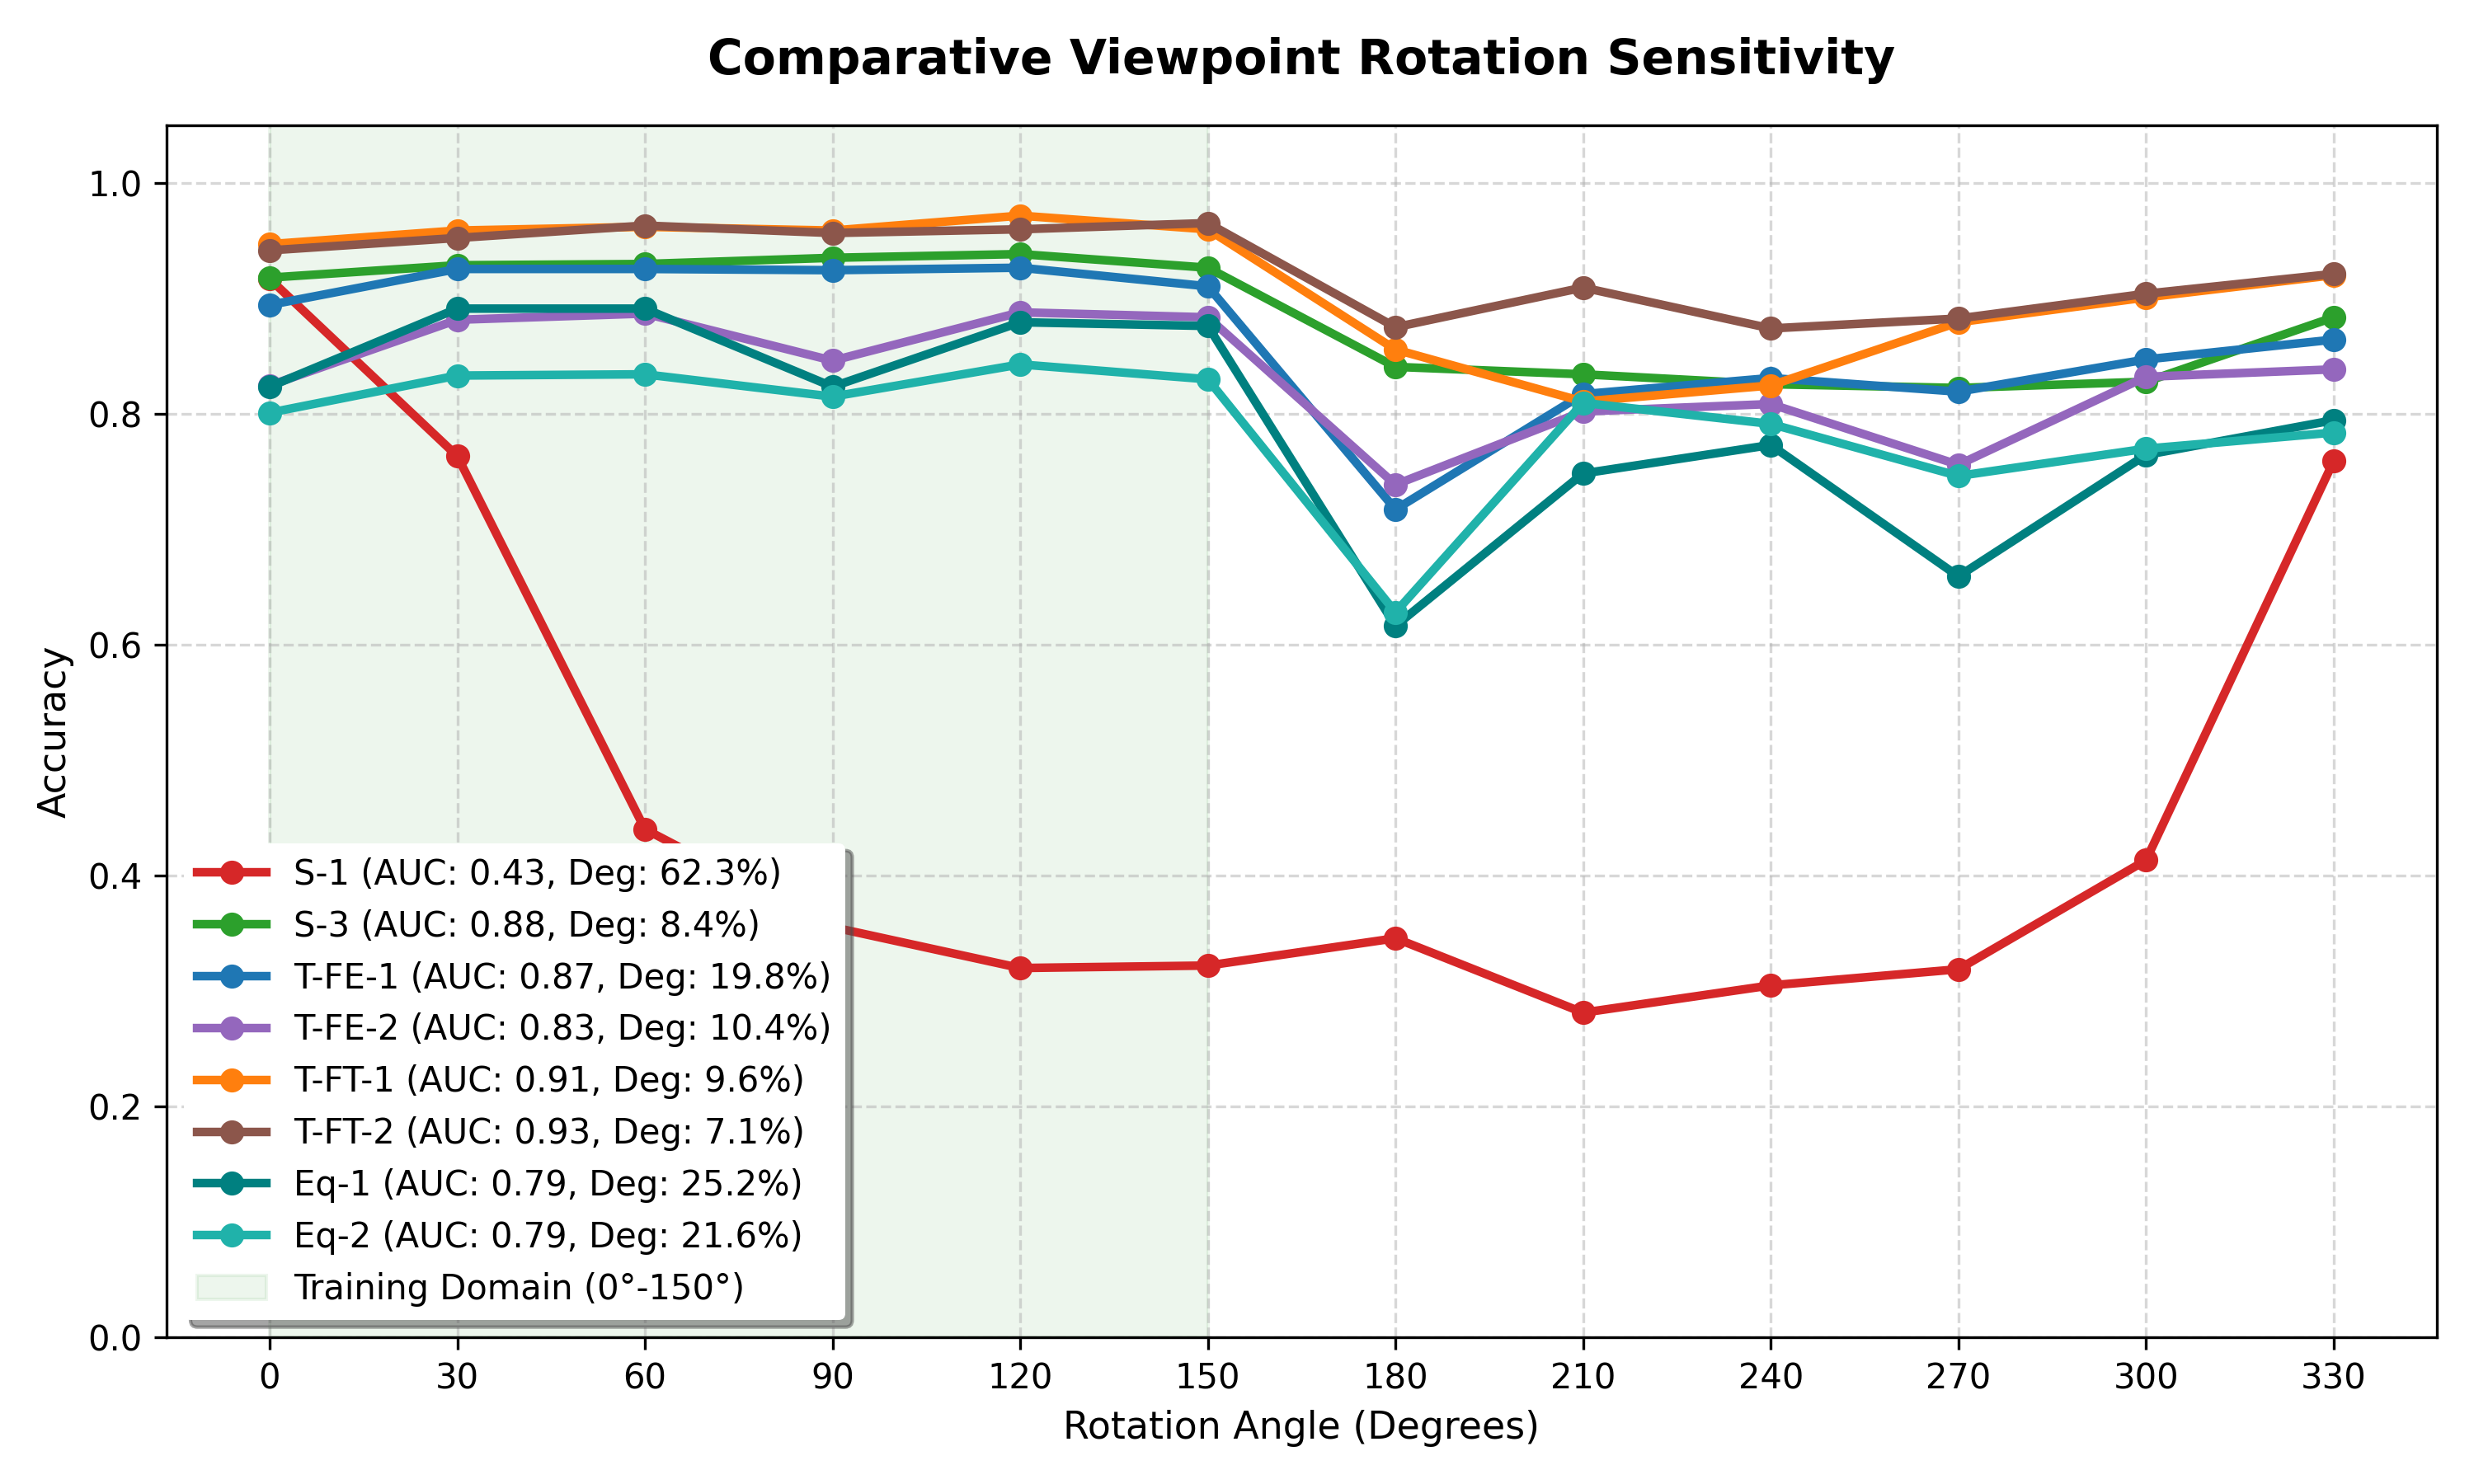

In [8]:
comparison_plot = "outputs/comparisons/rotation_curve_comparison.png"
if os.path.exists(comparison_plot):
    display(Image(filename=comparison_plot, width=800))
else:
    print("⚠️ Plot not found. Make sure to run the comparison code cell first.")

### 🌀 Individual Confusion Matrices

Load and view the individual category-wise confusion matrices for any experiment below.


🖼️ Confusion Matrix for Eq-1:


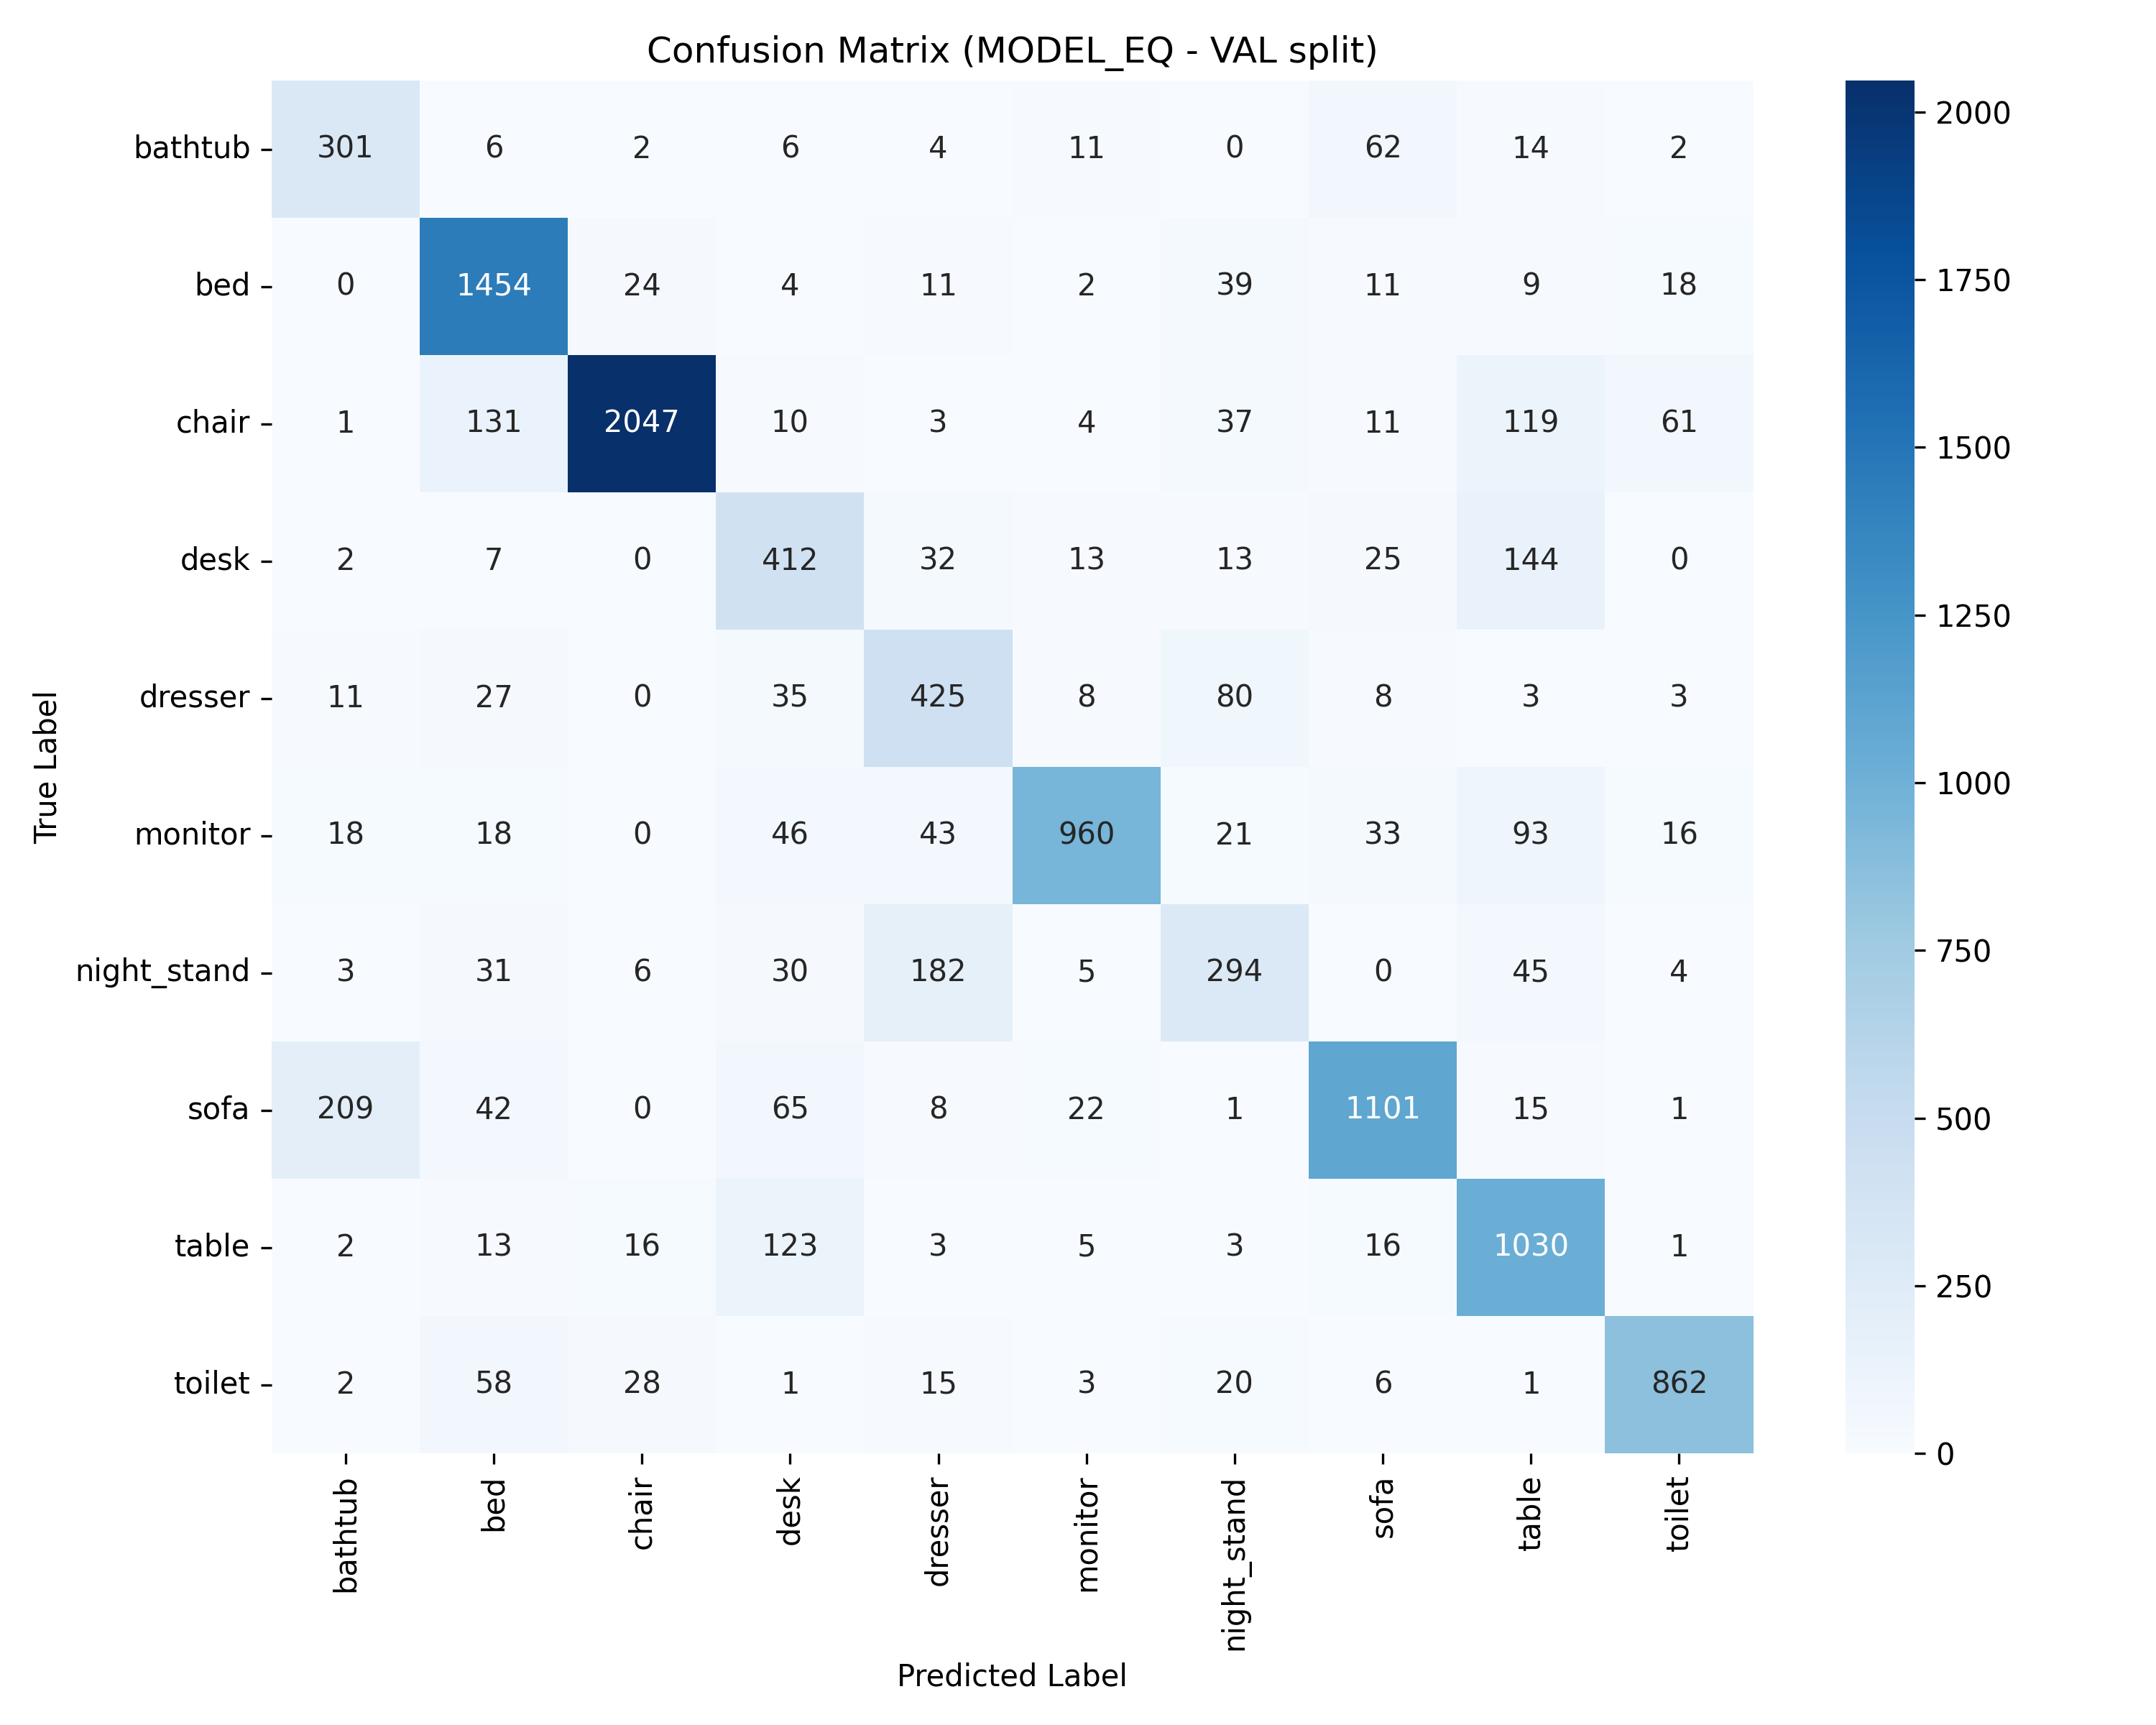

In [9]:
def show_confusion_matrix(exp_name):
    path = f"outputs/{exp_name}/figures/confusion_matrix.png"
    if os.path.exists(path):
        print(f"\n🖼️ Confusion Matrix for {exp_name}:")
        display(Image(filename=path, width=600))
    else:
        print(f"⚠️ Confusion Matrix plot not found at {path}")

show_confusion_matrix("Eq-1")
